In [460]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras.layers import LSTM, Dense, Dropout, SimpleRNN, GRU
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import keras_tuner as kt


Understanding dataset nature

In [364]:
data = pd.read_csv('AEP_hourly.csv')
data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [365]:
data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [366]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  str    
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1.9 MB


Preparing data for time series forecasting

In [367]:
data['Datetime'] = pd.to_datetime(data['Datetime'])

In [368]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121273 non-null  datetime64[us]
 1   AEP_MW    121273 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.9 MB


In [369]:
data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [370]:
data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [371]:
data.set_index('Datetime', inplace = True)

In [372]:
data.head()

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


EDA

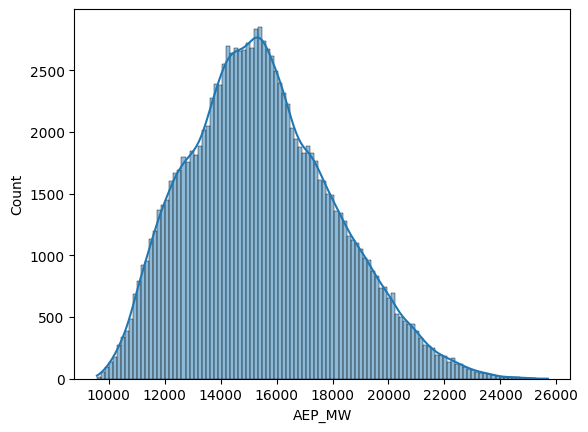

In [373]:
plt.figure()
sns.histplot(data['AEP_MW'], kde = True)
plt.show()

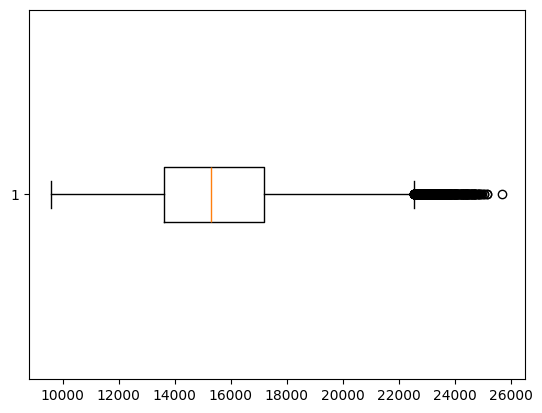

In [374]:
plt.boxplot(data, vert = False)
plt.show()

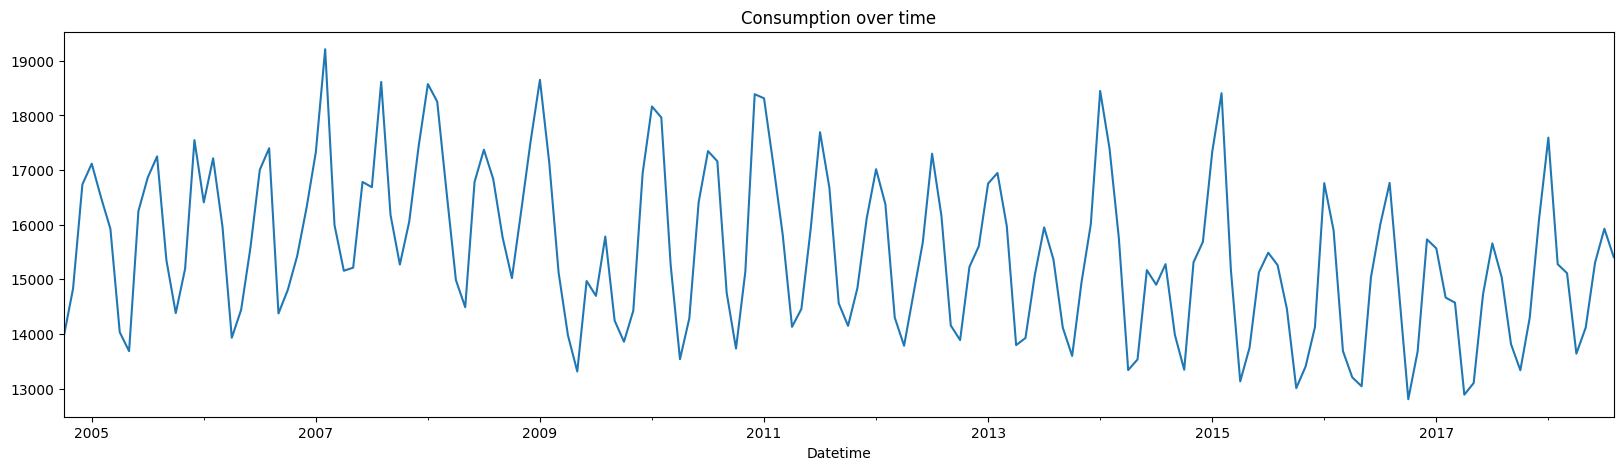

In [375]:
data_2 = data[['AEP_MW']].resample('ME').mean().copy()
data_2['AEP_MW'].plot(title=f"Consumption over time", figsize=(20, 5))
plt.show()

Train test Split

In [376]:
size = int(len(data_2)*0.8)
train_dataset = data_2.iloc[:size].copy()
test_dataset = data_2.iloc[size:].copy()

In [377]:
print(f"p_value: {sts.adfuller(train_dataset['AEP_MW'])[1]}")

p_value: 0.6416605289899769


In [378]:
train_dataset[['AEP_MW']]

,AEP_MW
Datetime,
2004-10-31,13947.537736
2004-11-30,14830.440278
2004-12-31,16737.720430
2005-01-31,17117.088710
2005-02-28,16496.644345
...,...
2015-06-30,15126.598611
2015-07-31,15487.528226
2015-08-31,15260.602151


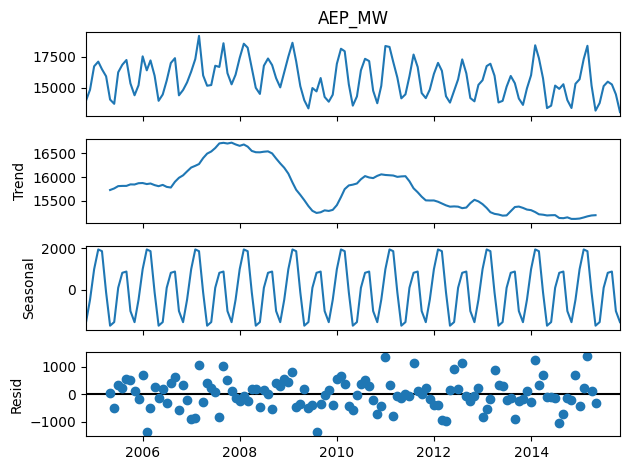

In [379]:
s_dec_additive = seasonal_decompose(train_dataset['AEP_MW'], model='additive')
s_dec_additive.plot()
plt.show()

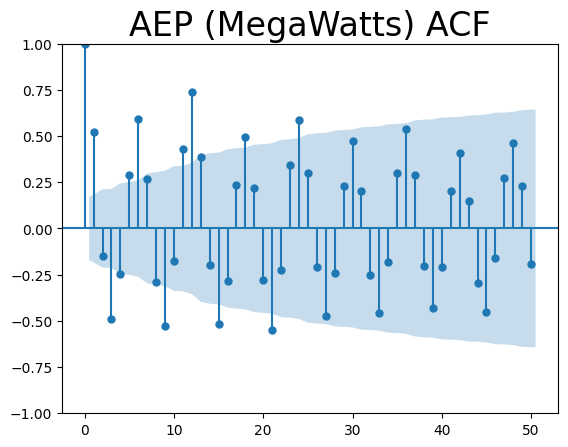

In [380]:
sgt.plot_acf(train_dataset['AEP_MW'], lags=50)
plt.title("AEP (MegaWatts) ACF", size=24)    
plt.show()

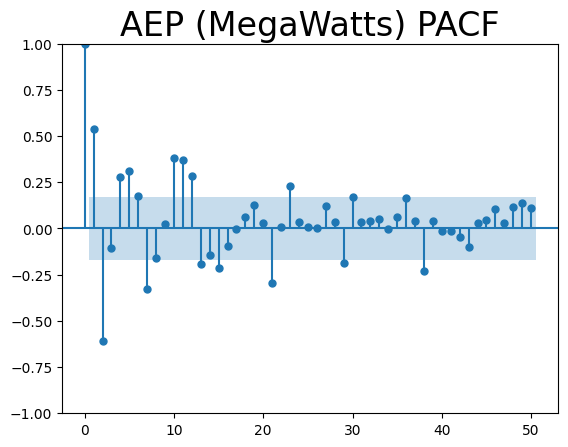

In [381]:
sgt.plot_pacf(train_dataset['AEP_MW'], lags=50, method='ols')
plt.title("AEP (MegaWatts) PACF", size=24)
plt.show()

In [382]:
stationary_data = train_dataset[['AEP_MW']].diff(12).dropna().copy()

In [383]:
stationary_data

,AEP_MW
Datetime,
2005-10-31,433.844498
2005-11-30,364.441667
2005-12-31,810.868280
2006-01-31,-707.252688
2006-02-28,719.383929
...,...
2015-06-30,-41.783333
2015-07-31,585.903226
2015-08-31,-17.698925


In [384]:
print(f"p_value: {sts.adfuller(stationary_data['AEP_MW'])[1]}")

p_value: 0.004762544539967442


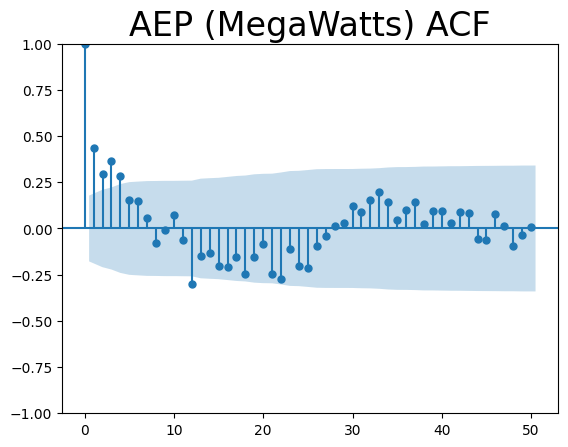

In [385]:
sgt.plot_acf(stationary_data['AEP_MW'], lags=50)
plt.title("AEP (MegaWatts) ACF", size=24)    
plt.show()

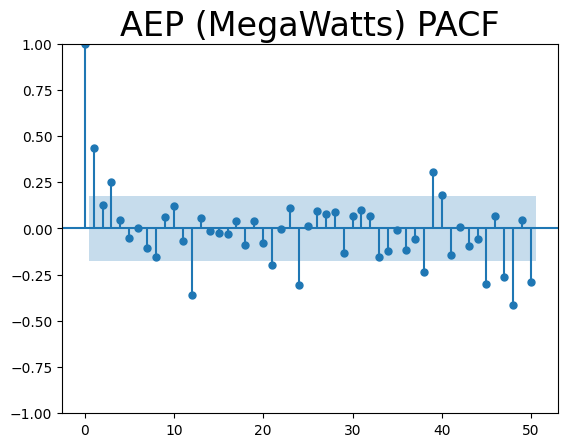

In [386]:
sgt.plot_pacf(stationary_data['AEP_MW'], lags=50, method='ols')
plt.title("AEP (MegaWatts) PACF", size=24)
plt.show()

In [387]:
model_sarima = SARIMAX(train_dataset['AEP_MW'],
                       order=(3, 1, 4),           
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit()
print(results_sarima.summary())

                                      SARIMAX Results                                       
Dep. Variable:                               AEP_MW   No. Observations:                  133
Model:             SARIMAX(3, 1, 4)x(1, 1, [1], 12)   Log Likelihood                -815.406
Date:                              Tue, 09 Jun 2026   AIC                           1650.813
Time:                                      10:42:45   BIC                           1677.160
Sample:                                  10-31-2004   HQIC                          1661.484
                                       - 10-31-2015                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2390      0.319      0.750      0.453      -0.386       0.864
ar.L2         -0.74

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [388]:
n_steps = len(test_dataset)
forecast_obj = results_sarima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

In [389]:
y_pred_train = results_sarima.fittedvalues

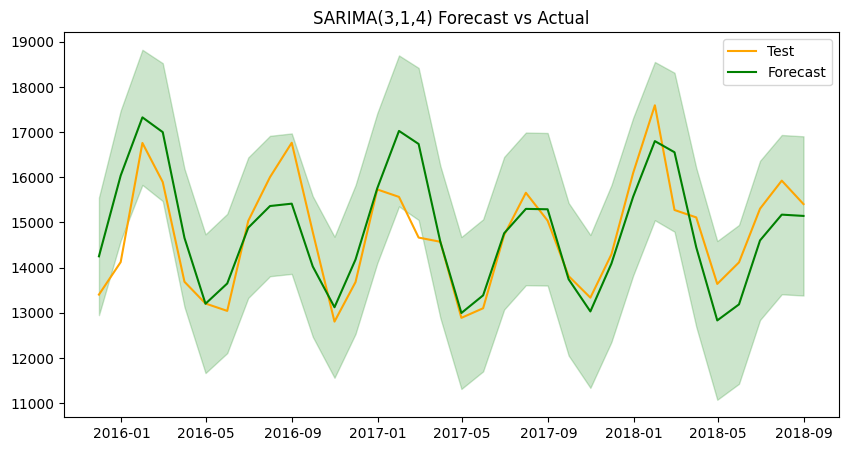

In [390]:
plt.figure(figsize=(10,5))
#plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('SARIMA(3,1,4) Forecast vs Actual')
plt.show()

In [391]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))
mae_train = mean_absolute_error(train_dataset['AEP_MW'], y_pred_train)
rmse_train = np.sqrt(mean_squared_error(train_dataset['AEP_MW'], y_pred_train))
train_r2 = r2_score(train_dataset['AEP_MW'], y_pred_train)
test_r2 = r2_score(test_dataset['AEP_MW'], y_pred)

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2: {train_r2:.2f}")
print(f"Test R2: {test_r2:.2f}")

Train MAE : 882.61
Test MAE : 636.34
Train RMSE: 1801.07
Test RMSE: 820.82
Train R2: -0.54
Test R2: 0.55


In [392]:
mape_train = (abs(train_dataset['AEP_MW'] - y_pred_train) / abs(train_dataset['AEP_MW'])).mean() * 100
mape_test  = (abs(test_dataset['AEP_MW']  - y_pred)  / abs(test_dataset['AEP_MW'])).mean()  * 100
print(f"Train MAPE: {mape_train:.2f}%")
print(f"Test MAPE:  {mape_test:.2f}%")

Train MAPE: 5.67%
Test MAPE:  4.28%


In [393]:
model_arima = ARIMA(train_dataset['AEP_MW'], order=(3,1,4))
results_arima = model_arima.fit()
results_arima.summary()

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 AEP_MW   No. Observations:                  133
Model:                 ARIMA(3, 1, 4)   Log Likelihood               -1087.398
Date:                Tue, 09 Jun 2026   AIC                           2190.797
Time:                        10:42:46   BIC                           2213.859
Sample:                    10-31-2004   HQIC                          2200.168
                         - 10-31-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0214      0.029      0.729      0.466      -0.036       0.079
ar.L2         -0.0113      0.029     -0.390      0.697      -0.068       0.045
ar.L3         -0.9832      0.028    -35.301      0.000      -1.038      -0.929
ma.L1         -0.2451      0.105     -2.337      0.019      -0.451      -0.040
ma.L2          0.0358      0.120      0.298      0.766      -0.200       0.272
ma.L3          0.9461      0.138      6.857      0.000       0.676       1.216
ma.L4         -0.1772      0.067     -2.630      0.009      -0.309      -0.045
sigma2      7.528e+05   2.85e-07   2.65e+12      0.000    7.53e+05    7.53e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.89   Jarque-Bera (JB):                 0.56
Prob(Q):                              0.17   Prob(JB):                         0.75
Heteroskedasticity (H):               0.45   Skew:                             0.10
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.15e+28. Standard errors may be unstable.
"""

In [394]:
n_steps = len(test_dataset)
forecast_obj = results_arima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

In [395]:
y_pred_train = results_arima.fittedvalues

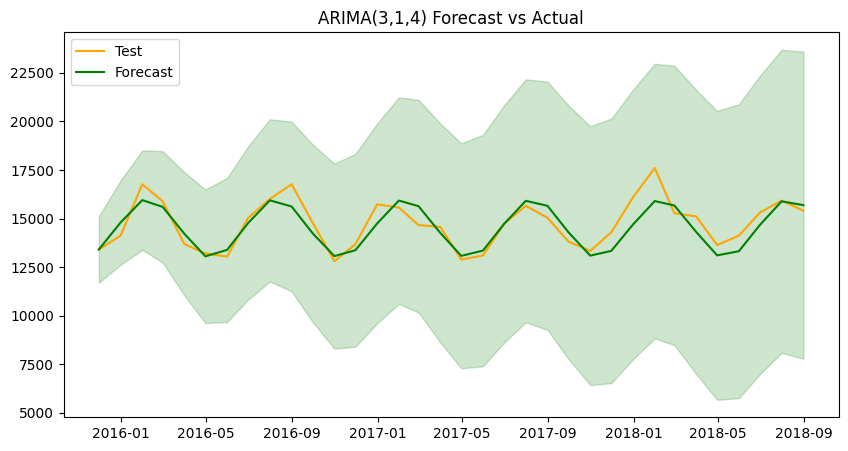

In [396]:
plt.figure(figsize=(10,5))
#plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('ARIMA(3,1,4) Forecast vs Actual')
plt.show()

In [397]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))
mae_train = mean_absolute_error(train_dataset['AEP_MW'], y_pred_train)
rmse_train = np.sqrt(mean_squared_error(train_dataset['AEP_MW'], y_pred_train))
train_r2 = r2_score(train_dataset['AEP_MW'], y_pred_train)
test_r2 = r2_score(test_dataset['AEP_MW'], y_pred)

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2: {train_r2:.2f}")
print(f"Test R2: {test_r2:.2f}")

Train MAE : 823.89
Test MAE : 517.45
Train RMSE: 1525.38
Test RMSE: 650.41
Train R2: -0.11
Test R2: 0.72


Comparing ARIMA and SARIMA Residuals

In [398]:
arima_resid = results_arima.resid
sarima_resid = results_sarima.resid

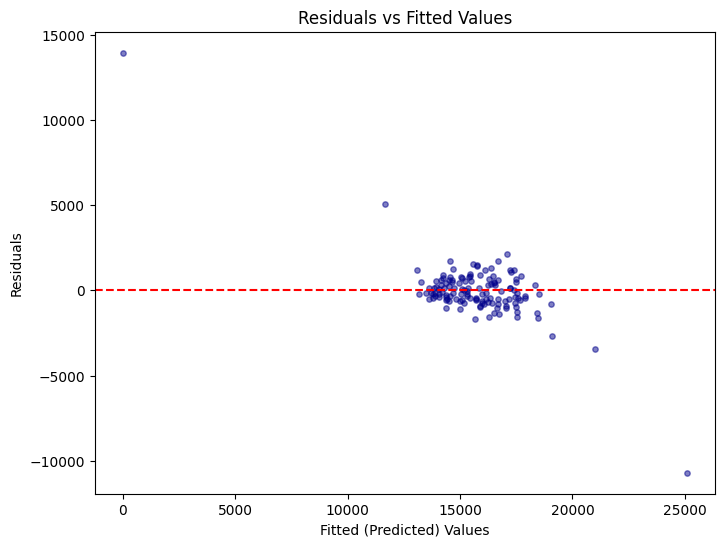

In [399]:
fitted_values = results_sarima.fittedvalues

plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, results_sarima.resid, alpha=0.5, color='darkblue', s=15)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted (Predicted) Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

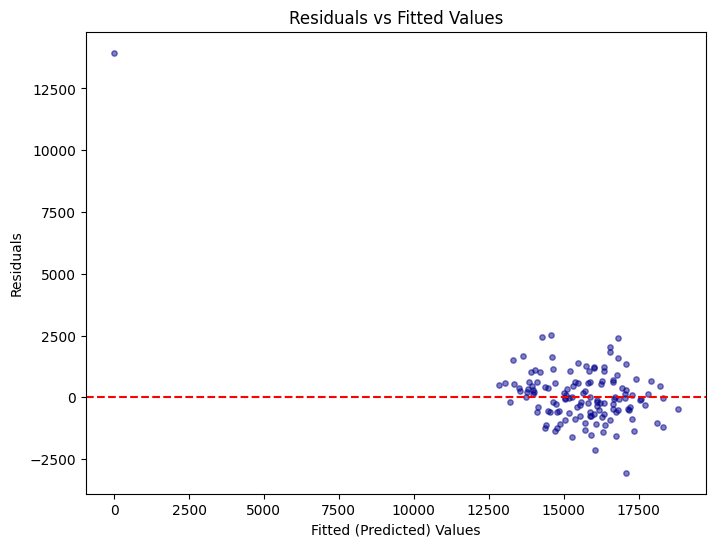

In [400]:
fitted_values = results_arima.fittedvalues

plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, results_arima.resid, alpha=0.5, color='darkblue', s=15)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted (Predicted) Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

In [401]:
train_proph = train_dataset.copy()
train_proph.reset_index(inplace = True)
train_proph.head()

,Datetime,AEP_MW
0,2004-10-31,13947.537736
1,2004-11-30,14830.440278
2,2004-12-31,16737.720430
3,2005-01-31,17117.088710
4,2005-02-28,16496.644345


In [402]:
train_proph = train_proph.rename(columns={'Datetime': 'ds', 'AEP_MW': 'y'})
train_proph.head()

,ds,y
0,2004-10-31,13947.537736
1,2004-11-30,14830.440278
2,2004-12-31,16737.720430
3,2005-01-31,17117.088710
4,2005-02-28,16496.644345


In [403]:
model = Prophet()
model.fit(train_proph)

10:42:46 - cmdstanpy - INFO - Chain [1] start processing
10:42:46 - cmdstanpy - INFO - Chain [1] done processing


In [404]:
test_proph = test_dataset.copy()
test_proph.reset_index(inplace = True)
test_proph.head()

,Datetime,AEP_MW
0,2015-11-30,13403.000000
1,2015-12-31,14123.189516
2,2016-01-31,16760.747312
3,2016-02-29,15895.386494
4,2016-03-31,13687.551817


In [405]:
test_proph = test_proph.rename(columns={'Datetime': 'ds', 'AEP_MW': 'y'})
test_proph.head()

,ds,y
0,2015-11-30,13403.000000
1,2015-12-31,14123.189516
2,2016-01-31,16760.747312
3,2016-02-29,15895.386494
4,2016-03-31,13687.551817


In [406]:
forecast = model.predict(test_proph)

In [407]:
forecast_train = model.predict(train_proph)

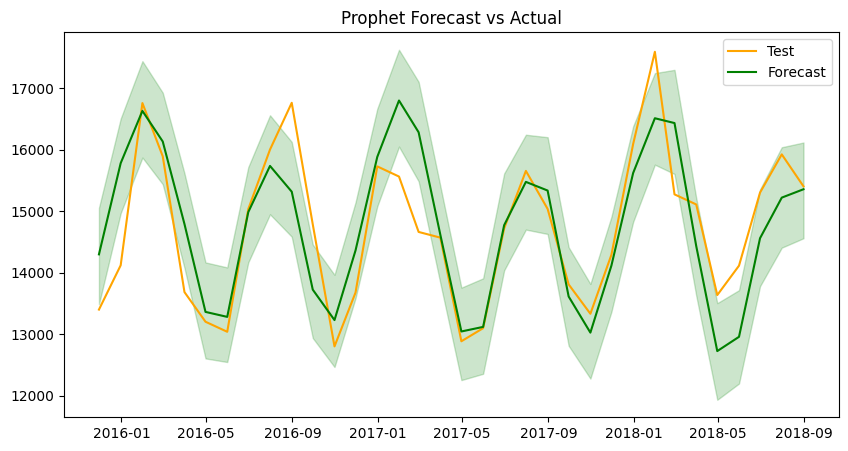

In [408]:
plt.figure(figsize=(10,5))
#plt.plot(train_proph['ds'], train_proph['y'], label='Train')
plt.plot(test_proph['ds'], test_proph['y'], label='Test', color='orange')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='green')
plt.fill_between(forecast['ds'],
                 forecast['yhat_upper'],
                 forecast['yhat_lower'],
                 color='green', alpha=0.2)
plt.legend()
plt.title('Prophet Forecast vs Actual')
plt.show()

In [409]:
mae = mean_absolute_error(test_proph['y'], forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test_proph['y'], forecast['yhat']))
mae_train = mean_absolute_error(train_proph['y'], forecast_train['yhat'])
rmse_train = np.sqrt(mean_squared_error(train_proph['y'], forecast_train['yhat']))
train_r2 = r2_score(train_proph['y'], forecast_train['yhat'])
test_r2 = r2_score(test_proph['y'], forecast['yhat'])

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2: {train_r2:.2f}")
print(f"Test R2: {test_r2:.2f}")

Train MAE : 469.87
Test MAE : 581.13
Train RMSE: 601.00
Test RMSE: 762.77
Train R2: 0.83
Test R2: 0.61


In [410]:
data_3 = data_2.copy()
data_3.head()

,AEP_MW
Datetime,
2004-10-31,13947.537736
2004-11-30,14830.440278
2004-12-31,16737.720430
2005-01-31,17117.088710
2005-02-28,16496.644345


In [411]:
#scaler = MinMaxScaler(feature_range=(0, 1))
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_3)

In [412]:
window_size = 12
X = []
y = []
target_dates = data_3.index[window_size:]

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False, random_state = 42
)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [413]:
model = Sequential()
model.add(SimpleRNN(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(SimpleRNN(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [414]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

#rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
#mae = np.mean(abs(y_test_1 - predictions))
#print(f'RMSE: {rmse:.2f}')
#print(f'MAE: {mae:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.8859 - val_loss: 0.2215
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7435 - val_loss: 0.5181
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4880 - val_loss: 0.2433
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5276 - val_loss: 0.2948
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3811 - val_loss: 0.4055
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4448 - val_loss: 0.2524
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3644 - val_loss: 0.2251
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4256 - val_loss: 0.2335
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3758 - val_loss: 0.1985
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2958 - val_loss: 0.1916
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3406 - val_loss: 0.2969
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3327 - val_lo

In [415]:
predictions_train = model.predict(X_train)
predictions_train = scaler.inverse_transform(predictions_train).flatten()
y_train_1 = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


In [416]:
mae = mean_absolute_error(y_test_1,predictions)
rmse = np.sqrt(mean_squared_error(y_test_1,predictions))
mae_train = mean_absolute_error(y_train_1,predictions_train)
rmse_train = np.sqrt(mean_squared_error(y_train_1,predictions_train))
train_r2 = r2_score(y_train_1,predictions_train)
test_r2 = r2_score(y_test_1, predictions)

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2 Score: {train_r2}")
print(f"Test R2 Score: {test_r2}")

Train MAE : 536.11
Test MAE : 697.78
Train RMSE: 655.40
Test RMSE: 843.56
Train R2 Score: 0.8025986071018042
Test R2 Score: 0.5020502485188783


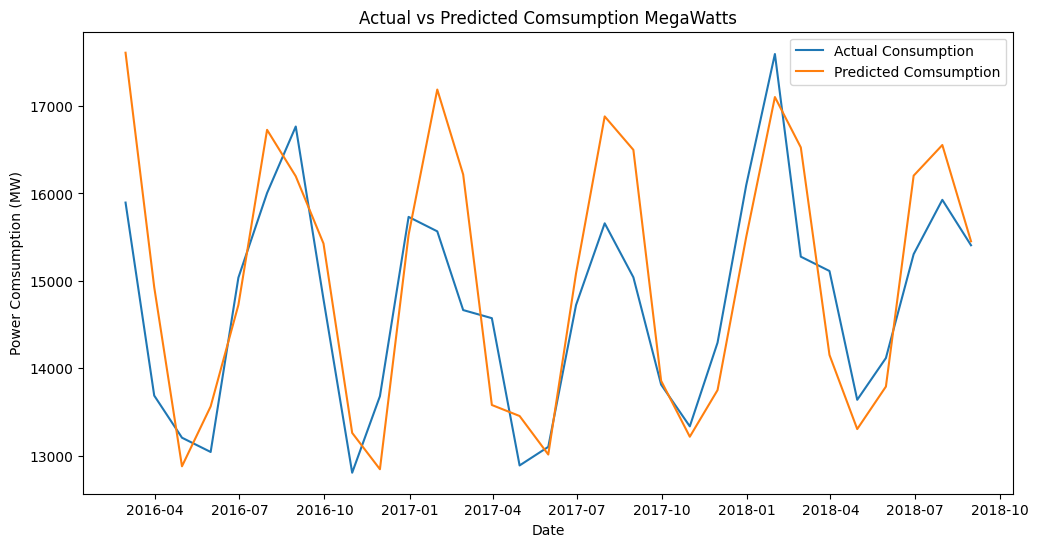

In [417]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Comsumption (MW)')
plt.legend()
plt.show()

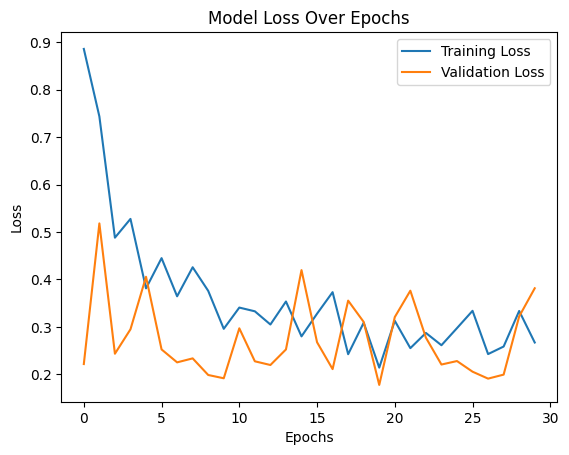

In [418]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model = Sequential()
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.35))
model.add(LSTM(units=128))
model.add(Dropout(0.35))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [436]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

#rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
#mae = np.mean(abs(y_test_1 - predictions))
#print(f'RMSE: {rmse:.2f}')
#print(f'MAE: {mae:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.9829 - val_loss: 1.3133
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.9428 - val_loss: 1.3078
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9156 - val_loss: 1.2650
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8982 - val_loss: 1.2174
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.8561 - val_loss: 1.1535
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8173 - val_loss: 1.0836
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8041 - val_loss: 1.0620
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.7829 - val_loss: 1.0256
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.7099 - val_loss: 1.1369
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.6871 - val_loss: 1.1479
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6708 - val_loss: 0.8895
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6484 - val_lo

In [437]:
predictions_train = model.predict(X_train)
predictions_train = scaler.inverse_transform(predictions_train).flatten()
y_train_1 = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

mae = mean_absolute_error(y_test_1,predictions)
rmse = np.sqrt(mean_squared_error(y_test_1,predictions))
mae_train = mean_absolute_error(y_train_1,predictions_train)
rmse_train = np.sqrt(mean_squared_error(y_train_1,predictions_train))
train_r2 = r2_score(y_train_1,predictions_train)
test_r2 = r2_score(y_test_1, predictions)

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2 Score: {train_r2}")
print(f"Test R2 Score: {test_r2}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
Train MAE : 663.16
Test MAE : 803.80
Train RMSE: 825.67
Test RMSE: 1067.07
Train R2 Score: 0.6867089067711905
Test R2 Score: 0.20320584950864973


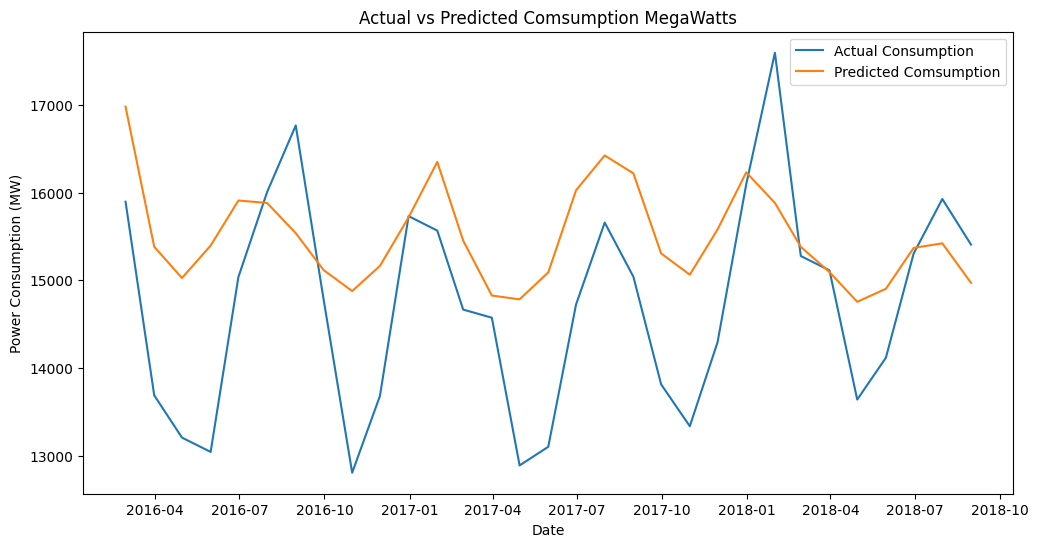

In [422]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Consumption (MW)')
plt.legend()
plt.show()

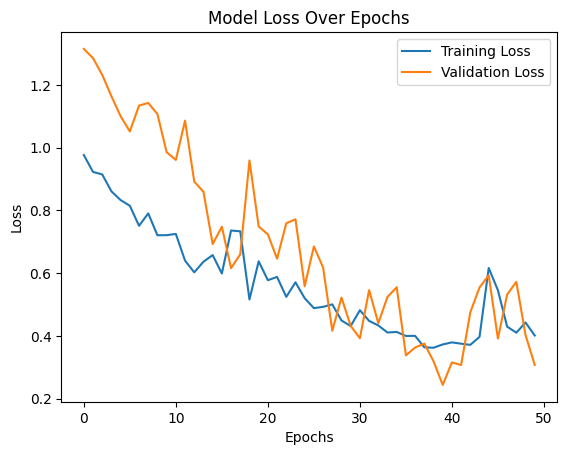

In [259]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [456]:
model = Sequential()
model.add(GRU(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.3))
model.add(GRU(units=128))
model.add(Dropout(0.3))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [457]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

#rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
#mae = np.mean(abs(y_test_1 - predictions))
#print(f'RMSE: {rmse:.2f}')
#print(f'MAE: {mae:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - loss: 0.9846 - val_loss: 1.3367
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9411 - val_loss: 1.3193
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9073 - val_loss: 1.2813
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.8626 - val_loss: 1.2166
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.7916 - val_loss: 1.1372
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.7346 - val_loss: 1.0826
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.6542 - val_loss: 0.9927
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.6185 - val_loss: 0.8812
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5312 - val_loss: 0.7663
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5037 - val_loss: 0.6947
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4665 - val_loss: 0.6415
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4116 - val_l

In [458]:
predictions_train = model.predict(X_train)
predictions_train = scaler.inverse_transform(predictions_train).flatten()
y_train_1 = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

mae = mean_absolute_error(y_test_1,predictions)
rmse = np.sqrt(mean_squared_error(y_test_1,predictions))
mae_train = mean_absolute_error(y_train_1,predictions_train)
rmse_train = np.sqrt(mean_squared_error(y_train_1,predictions_train))
train_r2 = r2_score(y_train_1,predictions_train)
test_r2 = r2_score(y_test_1, predictions)

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2 Score: {train_r2}")
print(f"Test R2 Score: {test_r2}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  
Train MAE : 533.05
Test MAE : 510.96
Train RMSE: 671.35
Test RMSE: 670.00
Train R2 Score: 0.7928795308191853
Test R2 Score: 0.6858697762256962


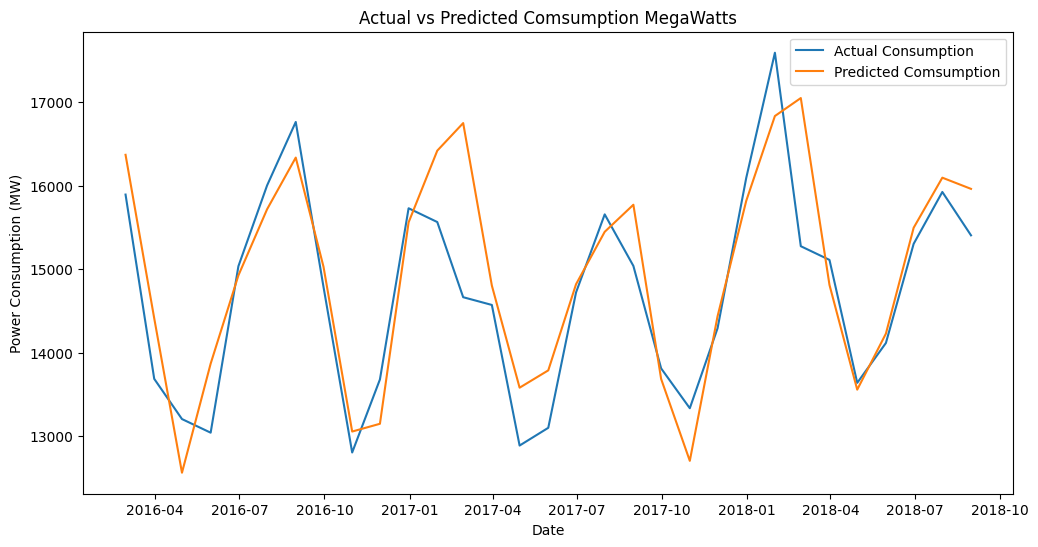

In [263]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Consumption (MW)')
plt.legend()
plt.show()

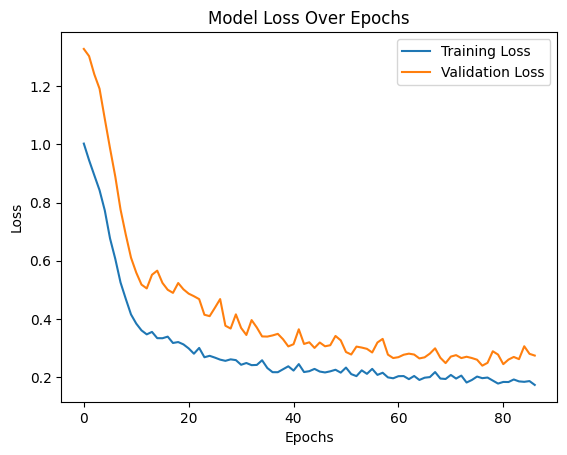

In [264]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [338]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [351]:
X_train, y_train = train_proph[['ds']], train_proph[['y']]
X_test, y_test = test_proph[['ds']], test_proph[['y']]

In [352]:
rf_model.fit(X_train, y_train)

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [355]:
train_preds_rf = rf_model.predict(X_train)
test_preds_rf = rf_model.predict(X_test)

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_rf)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_rf)}")
print(f"Training RMSE score: {np.sqrt(mean_squared_error(y_train, train_preds_rf))}")
print(f"Testing RMSE score: {np.sqrt(mean_squared_error(y_test, test_preds_rf))}")
print(f"Training R2 score: {r2_score(y_train, train_preds_rf)}")
print(f'Testing R2 score: {r2_score(y_test,test_preds_rf)}')

Training MAE score: 371.8181506643084
Testing MAE score: 1350.8661828167328
Training RMSE score: 432.1631876366275
Testing RMSE score: 1682.0142581915593
Training R2 score: 0.9111742192635577
Testing R2 score: -0.902824338387646


In [357]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [358]:
gb_model.fit(X_train, y_train)

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\sklearn\ensemble\_gb.py:691: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [361]:
train_preds_gb = gb_model.predict(X_train)
test_preds_gb = gb_model.predict(X_test)

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_gb)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_gb)}")
print(f"Training RMSE score: {np.sqrt(mean_squared_error(y_train, train_preds_gb))}")
print(f"Testing RMSE score: {np.sqrt(mean_squared_error(y_test, test_preds_gb))}")
print(f"Training R2 score: {r2_score(y_train, train_preds_gb)}")
print(f'Testing R2 score: {r2_score(y_test,test_preds_gb)}')

Training MAE score: 511.9094477284327
Testing MAE score: 1542.4493371759509
Training RMSE score: 651.5963068346082
Testing RMSE score: 1905.9683210758037
Training R2 score: 0.7980700576764805
Testing R2 score: -1.4432657544335883


Hyperparameter Tune best model (GRU)

In [462]:
window_size = 12
X = []
y = []
target_dates = data_3.index[window_size:]

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False, random_state = 42
)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [463]:
def build_model(hp):
    model = Sequential()
    
    hp_units_1 = hp.Int('units_1', min_value=32, max_value=256, step=32)
    model.add(GRU(units=hp_units_1, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_1))
    
    hp_units_2 = hp.Int('units_2', min_value=32, max_value=256, step=32)
    model.add(GRU(units=hp_units_2))
    
    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_2))
    
    model.add(Dense(1))
    
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    optimizer = Adam(learning_rate=hp_learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    return model

In [464]:
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=15,          
    executions_per_trial=1, 
    directory='tuning_dir',
    project_name='gru_hypertuning'
)

In [466]:
tuner.search(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Trial 15 Complete [00h 00m 06s]
val_loss: 1.3025729656219482

Best val_loss So Far: 0.21557539701461792
Total elapsed time: 00h 02m 23s


In [467]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete.
Optimal GRU units layer 1: {best_hps.get('units_1')}
Optimal Dropout layer 1: {best_hps.get('dropout_1')}
Optimal GRU units layer 2: {best_hps.get('units_2')}
Optimal Dropout layer 2: {best_hps.get('dropout_2')}
Optimal Learning Rate: {best_hps.get('learning_rate')}
""")

best_model = tuner.get_best_models(num_models=1)[0]

predictions = best_model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


The hyperparameter search is complete.
Optimal GRU units layer 1: 64
Optimal Dropout layer 1: 0.1
Optimal GRU units layer 2: 224
Optimal Dropout layer 2: 0.5
Optimal Learning Rate: 0.01



c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


In [468]:
predictions_train = best_model.predict(X_train)
predictions_train = scaler.inverse_transform(predictions_train).flatten()
y_train_1 = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

mae = mean_absolute_error(y_test_1,predictions)
rmse = np.sqrt(mean_squared_error(y_test_1,predictions))
mae_train = mean_absolute_error(y_train_1,predictions_train)
rmse_train = np.sqrt(mean_squared_error(y_train_1,predictions_train))
train_r2 = r2_score(y_train_1,predictions_train)
test_r2 = r2_score(y_test_1, predictions)

print(f"Train MAE : {mae_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Train R2 Score: {train_r2}")
print(f"Test R2 Score: {test_r2}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 
Train MAE : 518.09
Test MAE : 503.93
Train RMSE: 647.51
Test RMSE: 640.77
Train R2 Score: 0.8073263737103397
Test R2 Score: 0.7126836567640593
